In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

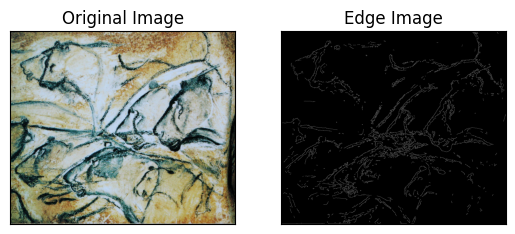

In [2]:
img = cv2.imread('dataset\chauvet\panel-of-the-lions-detail-chauvet-cave-6345.jpg', cv2.IMREAD_COLOR)
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_filt = cv2.bilateralFilter(img_gray, 9, 75, 75)
edges = cv2.Canny(img_filt,100,200)
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
 
plt.show()

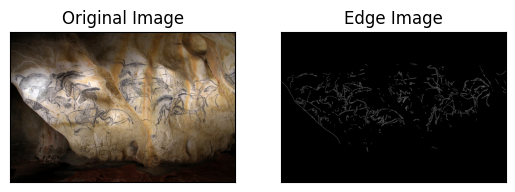

In [6]:
img = cv2.imread('dataset\chauvet\panel-of-the-horses-chauvet-cave-replica-6349.jpg', cv2.IMREAD_COLOR)
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_filt = cv2.bilateralFilter(img_gray, 9, 75, 75)
edges = cv2.Canny(img_filt,80,150)
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
cv2.imwrite('edges_rhino.png', edges)
 
plt.show()

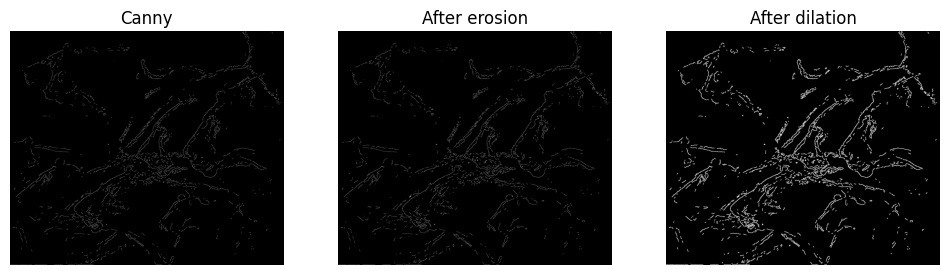

In [15]:
# --- Lecture image ---
img = cv2.imread(
    r'dataset\chauvet\panel-of-the-lions-detail-chauvet-cave-6345.jpg',
    cv2.IMREAD_COLOR
)

# --- Prétraitement ---
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (7, 7), 2)

# --- Canny ---
edges = cv2.Canny(img_blur, 150, 200)

# --- Morphologie ---
kernel = np.ones((3, 3), np.uint8)

# Dilatation
edges_dilated = cv2.dilate(edges, kernel, iterations=1)

# Érosion
edges_eroded = cv2.erode(edges_dilated, kernel, iterations=1)

cv2.imwrite('edges_rhino_fermeture.png', edges_eroded)

# --- Affichage ---
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(edges, cmap='gray')
plt.title("Canny")
plt.axis('off')

plt.subplot(133)
plt.imshow(edges_dilated, cmap='gray')
plt.title("After dilation")
plt.axis('off')

plt.subplot(132)
plt.imshow(edges_eroded, cmap='gray')
plt.title("After erosion")
plt.axis('off')

plt.show()